In [3]:
import numpy as np
import astropy.units as u
from scipy.integrate import quad #this will be used for the integral
from astropy.cosmology import FlatLambdaCDM
import matplotlib.pyplot as plt

In [4]:
#Roman values
#known f_lim from Wang et al.
f_lim = 1e-16 * u.erg / (u.s * u.cm**2)
survey_area = 2000
sky_fraction = survey_area/41253

#Kulkarni et al used flat cosmology
cosmo = FlatLambdaCDM(H0 = 70, Om0 = 0.3) # at z = 0

#Magnitude cutoff
M_min = -23 #L_min note L_max can be anything??

In [5]:
#QLF UV Function based on table 2 of Kulkarni (double power law)
def qlf(M, log_phi_star, M_star, alpha, beta):
    phi_star = 10**log_phi_star
    phi = phi_star / (10**(0.4*(alpha+1)*(M-M_star)) + 10**(0.4*(beta+1)*(M-M_star)))
    return phi   

In [6]:
#plug in the data for each of the redshift range fromt table 2 with redshift ranges
# Each row has redshift_range, z_min, z_max, overlapping lines, log_phi_star, M_star, alpha, beta
bins = [

    # Halpha + Hbeta
    ["1.1 < z < 1.2", 1.1, 1.2, "Halpha + Hbeta", -6.62, -25.24, -4.24, -1.84],
    ["1.2 < z < 1.4",1.2, 1.4, "Halpha + Hbeta", -6.52, -25.41, -4.02, -1.88],
    ["1.4 < z < 1.6", 1.4, 1.6, "Halpha + Hbeta", -6.59, -25.77, -4.35, -1.87],
    ["1.6 < z < 1.8", 1.6, 1.8, "Halpha + Hbeta", -6.29, -25.56, -3.94, -1.69],
    ["1.8 < z < 1.9", 1.8, 1.9, "Halpha + Hbeta", -6.79, -26.35, -4.26, -1.98],

    # Hbeta + Mg II
    ["2.6 < z < 2.7", 2.6, 2.7, "Hbeta + Mg II", -5.98, -25.16, -3.13, -1.05],
    ["2.7 < z < 2.8", 2.7, 2.8, "Hbeta + Mg II", -6.29, -25.94, -3.78, -1.34],
    ["2.8 < z < 2.9", 2.8, 2.9, "Hbeta + Mg II", -6.46, -26.22, -3.61, -1.46],
    ["2.9 < z < 3.0", 2.9, 3.0, "Hbeta + Mg II", -6.76, -26.52, -5.01, -1.71],

    # Mg II + C III]
    ["4.2 < z < 4.7",4.2, 4.7, "Mg II + C III]", -8.32, -27.37, -4.19, -2.20],
    ["4.7 < z < 5.5", 4.7, 5.5, "Mg II + C III]", -9.03, -27.89, -4.55, -2.31],

    # Mg II + C III] + C IV
    ["5.5 < z < 5.9", 5.5, 5.9, "Mg II + C III] + C IV", -10.66, -29.19, -5.00, -2.40],

    # C III] + C IV
    ["5.9 < z < 6.5", 5.9, 6.5, "C III] + C IV", -10.66, -29.19, -5.00, -2.40],
]

In [7]:
#for M_limit in [-24, -21]:

M_min_values = np.linspace(-29.9, -23)

N_QSO = []

# this will save the redshift-bin results only for the final M_min value
final_bin_results = []

for M_min_val in M_min_values:
    
    total_qsos = 0
    bin_results = []

    for rows in bins:
        
        redshift_range = rows[0]
        z_min = rows[1]
        z_max = rows[2]
        lines = rows[3]
        log_phi_star = rows[4]
        M_star = rows[5]
        alpha = rows[6]
        beta = rows[7]

        z_middle = (z_min + z_max)/2

        # luminosity distance
        d_L = cosmo.luminosity_distance(z_middle).to(u.cm)
    
        # minimum line luminosity Roman could detect
        L_min = (4 * np.pi * d_L**2 * f_lim).to(u.erg / u.s)

        number_density, error = quad(qlf,-30, M_min_val,
            args=(log_phi_star, M_star, alpha, beta))

        # comoving volume for each bin
        full_sky_volume = (cosmo.comoving_volume(z_max) - cosmo.comoving_volume(z_min))

        roman_volume = full_sky_volume * sky_fraction

        # number of QSOs
        number_of_qsos = number_density * roman_volume.to_value(u.Mpc**3)

        total_qsos = total_qsos + number_of_qsos

        # save results instead of printing immediately
        bin_results.append([
            z_min,
            z_max,
            lines,
            d_L.to(u.Gpc),
            L_min,
            number_density,
            roman_volume,
            number_of_qsos])

    N_QSO.append(total_qsos)

    # save only the final M_min value summary, which is M1450 = -23
    final_bin_results = bin_results
    final_total_qsos = total_qsos
    final_M_min = M_min_val

In [8]:
print("----------------------------------------")
print("Final limiting magnitude M1450:", f"{final_M_min:.2f}")
print("----------------------------------------")

for result in final_bin_results:
    
    z_min = result[0]
    z_max = result[1]
    lines = result[2]
    d_L = result[3]
    L_min = result[4]
    number_density = result[5]
    roman_volume = result[6]
    number_of_qsos = result[7]

    print("----------------------------------------")
    print("Redshift range:", z_min, "< z <", z_max)
    print("Roman lines:", lines)
    print("Luminosity distance:", d_L)
    print("Minimum line luminosity:", f"{L_min.value:.2e}", "erg/s")
    print("QSO number density:", f"{number_density:.2e}", "Mpc^-3")
    print("Roman comoving volume:", f"{roman_volume.value:.2e}", "Mpc^3")
    print("Expected number of QSOs:", f"{number_of_qsos:.0f}")

print("----------------------------------------")
print("Total expected QSOs in all listed bins:")
print(f"{final_total_qsos:.0f}")

----------------------------------------
Final limiting magnitude M1450: -23.00
----------------------------------------
----------------------------------------
Redshift range: 1.1 < z < 1.2
Roman lines: Halpha + Hbeta
Luminosity distance: 7.854775483904881 Gpc
Minimum line luminosity: 7.38e+41 erg/s
QSO number density: 1.38e-06 Mpc^-3
Roman comoving volume: 1.81e+09 Mpc^3
Expected number of QSOs: 2501
----------------------------------------
Redshift range: 1.2 < z < 1.4
Roman lines: Halpha + Hbeta
Luminosity distance: 9.141434764157829 Gpc
Minimum line luminosity: 1.00e+42 erg/s
QSO number density: 2.14e-06 Mpc^-3
Roman comoving volume: 3.95e+09 Mpc^3
Expected number of QSOs: 8459
----------------------------------------
Redshift range: 1.4 < z < 1.6
Roman lines: Halpha + Hbeta
Luminosity distance: 10.909639415584016 Gpc
Minimum line luminosity: 1.42e+42 erg/s
QSO number density: 2.56e-06 Mpc^-3
Roman comoving volume: 4.28e+09 Mpc^3
Expected number of QSOs: 10945
-------------------

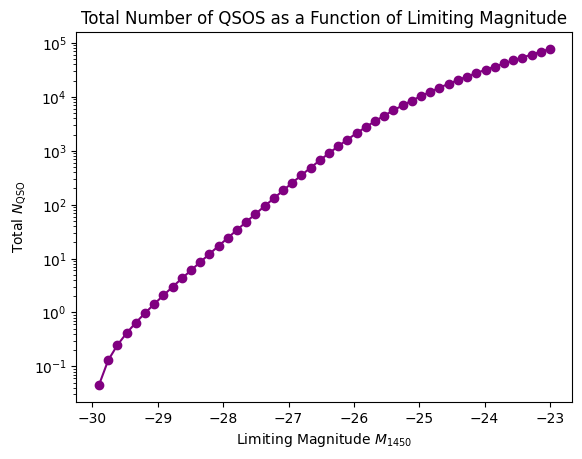

In [9]:
plt.plot(M_min_values, N_QSO, marker = "o", color = "purple")
plt.xlabel(r"Limiting Magnitude $M_{1450}$")
plt.ylabel(r"Total $N_{\rm QSO}$")
plt.title(r"Total Number of QSOS as a Function of Limiting Magnitude")

plt.yscale("log")
plt.show()


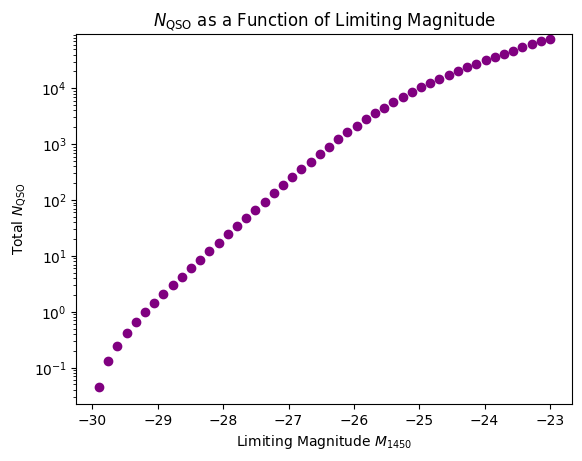

'\nUnits:\nQLF -> Mpc^-3 mag^-1\nNumber density (n_qso) -> Mpc^-3\nvolume -> Mpc^3\nM_1450 -> absolute manitude at 1450 angstrom (mag)\nN_QSO -> counts\n\n\n'

In [10]:
plt.scatter(M_min_values, N_QSO, color="purple")
plt.xlabel(r"Limiting Magnitude $M_{1450}$")
plt.ylabel(r"Total $N_{\rm QSO}$")
plt.title(r"$N_{\rm QSO}$ as a Function of Limiting Magnitude")

plt.yscale("log")

# make sure the lower values are visible
plt.ylim(min(N_QSO)*0.5, max(N_QSO)*1.2)

plt.show()

'''
Units:
QLF -> Mpc^-3 mag^-1
Number density (n_qso) -> Mpc^-3
volume -> Mpc^3
M_1450 -> absolute manitude at 1450 angstrom (mag)
N_QSO -> counts


'''